# Weekly Regime Clustering

Regime detection for university building energy consumption using weekly profiles (168-dim).

**Models compared:**
1. K-Means (baseline)
2. Gaussian Mixture Model (GMM)
3. Hierarchical Clustering
4. Hidden Markov Model (HMM)
5. Change Point Detection (PELT)

**Two normalization approaches:**
- Global StandardScaler (original)
- Per-week z-score normalization (trend-invariant, online-compatible)

In [32]:
import sys
sys.path.insert(0, r"c:\Projects Python\Project-I\Project-I\Project_I\src")

import os
os.chdir(r"c:\Projects Python\Project-I\Project-I\Project_I")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from scipy.cluster.hierarchy import dendrogram, linkage
from hmmlearn.hmm import GaussianHMM
import ruptures as rpt

from project_i.cluster_eval import ClusterEvaluator

sns.set_theme(style="whitegrid", palette="deep", font_scale=1.1)
plt.rcParams.update({"figure.figsize": (14, 5), "figure.dpi": 100})

## 1. Data Loading & Weekly Profiles

In [33]:
df = pd.read_csv("data/clean_energy_data.csv", index_col="timestamp")
df.index = pd.to_datetime(df.index, utc=True)

# Clean main meter — cap at 99.9th percentile
p999 = df["main_meter_power_kw"].quantile(0.999)
df["main_meter_clean_kw"] = df["main_meter_power_kw"].copy()
df.loc[df["main_meter_clean_kw"] > p999, "main_meter_clean_kw"] = np.nan

# Hourly resampling
hourly = df[["main_meter_clean_kw", "temp_c"]].resample("h").mean()
hourly_power = hourly["main_meter_clean_kw"]

print(f"Hourly: {len(hourly)} rows")
print(f"  main_meter missing: {hourly['main_meter_clean_kw'].isna().mean():.1%}")
print(f"  temp_c missing:     {hourly['temp_c'].isna().mean():.1%}")

Hourly: 87664 rows
  main_meter missing: 1.5%
  temp_c missing:     0.1%


In [34]:
# Pivot to weekly profiles: one row per week, 168 columns (dow*24 + hour)
hourly_df = hourly_power.to_frame()
hourly_df["week"] = hourly_power.index.to_period("W").start_time
hourly_df["dow_hour"] = hourly_power.index.dayofweek * 24 + hourly_power.index.hour

weekly_pivot = hourly_df.pivot_table(
    index="week", columns="dow_hour", values="main_meter_clean_kw", aggfunc="mean"
)

# Keep weeks with >= 120 valid hours
valid_wh = weekly_pivot.notna().sum(axis=1)
weekly_pivot = weekly_pivot[valid_wh >= 120]
weekly_pivot = weekly_pivot.interpolate(axis=1, limit=6).dropna()
dates_weekly = pd.to_datetime(weekly_pivot.index)

print(f"Weekly profiles: {len(weekly_pivot)} weeks x {weekly_pivot.shape[1]} dims")

Weekly profiles: 509 weeks x 168 dims


C:\Users\zaizzhaim\AppData\Local\Temp\ipykernel_5340\297293974.py:3: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  hourly_df["week"] = hourly_power.index.to_period("W").start_time


## 2. Normalization

Two approaches:
- **Global**: StandardScaler across all weeks (original approach — affected by trend)
- **Per-week**: z-score each week independently (mean=0, std=1) — removes trend, keeps only the *shape* of weekly consumption. Online-compatible.

In [35]:
# Global normalization (original)
scaler_global = StandardScaler()
X_global = scaler_global.fit_transform(weekly_pivot.values)

# Per-week normalization (trend-invariant)
weekly_values = weekly_pivot.values.copy()
row_means = weekly_values.mean(axis=1, keepdims=True)
row_stds = weekly_values.std(axis=1, keepdims=True)
row_stds[row_stds == 0] = 1  # avoid division by zero
X_perweek = (weekly_values - row_means) / row_stds

print(f"Global:   shape={X_global.shape}, mean~{X_global.mean():.2f}, std~{X_global.std():.2f}")
print(f"Per-week: shape={X_perweek.shape}, per-row mean~{X_perweek.mean(axis=1).mean():.2f}, "
      f"per-row std~{X_perweek.std(axis=1).mean():.2f}")

Global:   shape=(509, 168), mean~-0.00, std~1.00
Per-week: shape=(509, 168), per-row mean~-0.00, per-row std~1.00


## 3. PCA Reduction

Global PCA:   168 -> 26 components (95.0% var)
Per-week PCA: 168 -> 60 components (95.0% var)


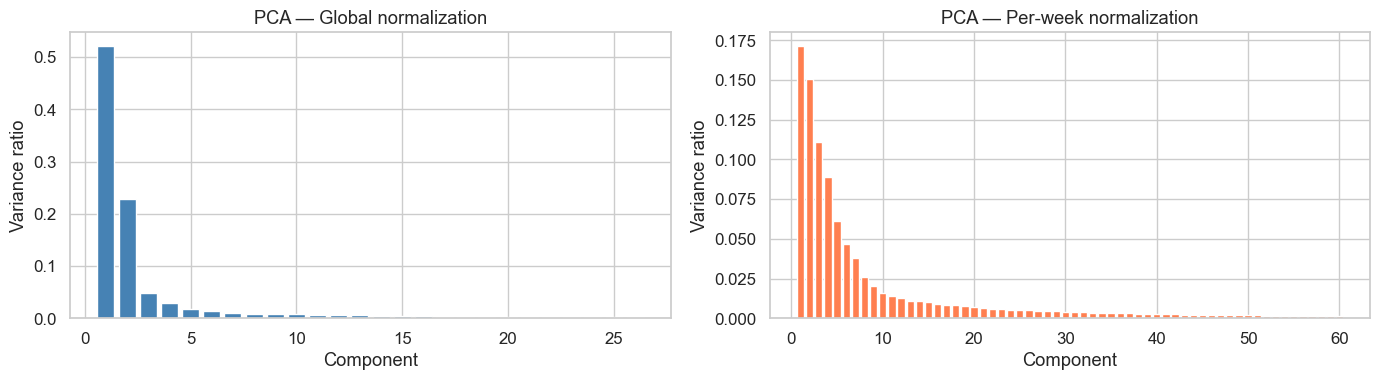

In [36]:
pca_global = PCA(n_components=0.95, random_state=42)
X_global_pca = pca_global.fit_transform(X_global)

pca_perweek = PCA(n_components=0.95, random_state=42)
X_perweek_pca = pca_perweek.fit_transform(X_perweek)

print(f"Global PCA:   168 -> {X_global_pca.shape[1]} components "
      f"({pca_global.explained_variance_ratio_.sum():.1%} var)")
print(f"Per-week PCA: 168 -> {X_perweek_pca.shape[1]} components "
      f"({pca_perweek.explained_variance_ratio_.sum():.1%} var)")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))
ax1.bar(range(1, len(pca_global.explained_variance_ratio_) + 1),
        pca_global.explained_variance_ratio_, color="steelblue")
ax1.set_title("PCA — Global normalization")
ax1.set_xlabel("Component")
ax1.set_ylabel("Variance ratio")

ax2.bar(range(1, len(pca_perweek.explained_variance_ratio_) + 1),
        pca_perweek.explained_variance_ratio_, color="coral")
ax2.set_title("PCA — Per-week normalization")
ax2.set_xlabel("Component")
ax2.set_ylabel("Variance ratio")
plt.tight_layout()
plt.show()

## 4. Choose Data for Models

Switch between global and per-week normalization here. Re-run all cells below after switching.

In [37]:
# ==== SWITCH HERE ====
USE_PERWEEK = True  # True = per-week z-score, False = global StandardScaler
# ====================

if USE_PERWEEK:
    X = X_perweek_pca
    NORM_LABEL = "per-week norm"
else:
    X = X_global_pca
    NORM_LABEL = "global norm"

print(f"Using: {NORM_LABEL}, shape={X.shape}")

Using: per-week norm, shape=(509, 60)


---
## Model 1: K-Means (baseline)

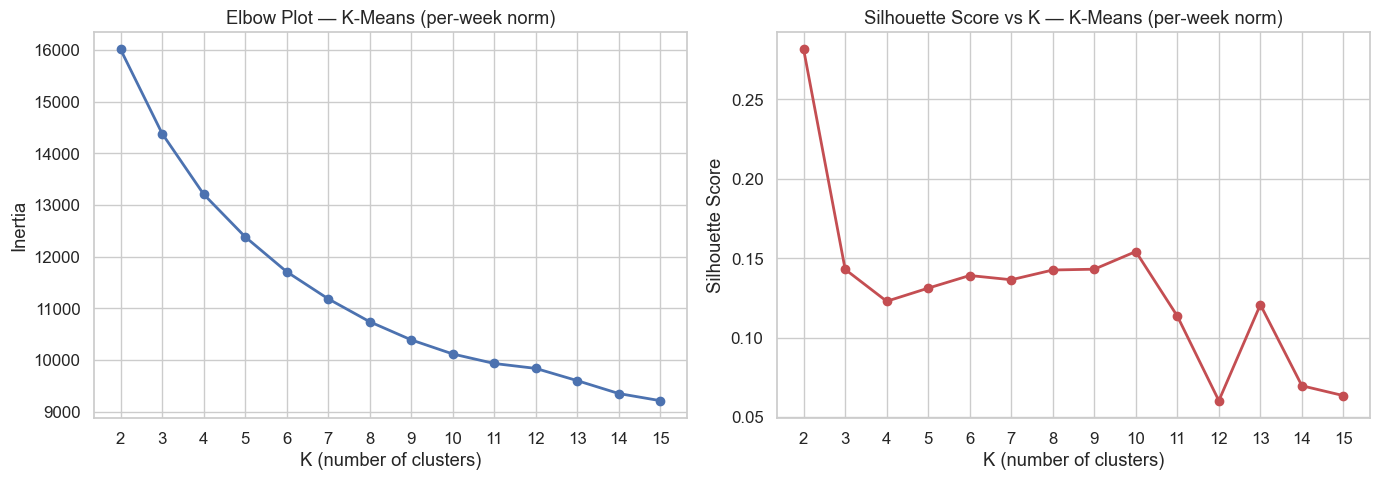

{2: 0.2814141662558322,
 3: 0.1429229682522711,
 4: 0.12284576816774238,
 5: 0.13112579804461502,
 6: 0.1390770092293647,
 7: 0.13639702667532103,
 8: 0.14254670496584892,
 9: 0.14304710061178544,
 10: 0.1541722713198148,
 11: 0.11350387561460705,
 12: 0.06023884064505826,
 13: 0.1207090416890156,
 14: 0.06964780028048616,
 15: 0.06343353381075374}

In [38]:
ClusterEvaluator.plot_k_selection(X, k_range=range(2, 16), name=f"K-Means ({NORM_LABEL})")


  K-Means K=7 (per-week norm) — K=7
  Silhouette score:       0.1364
  Calinski-Harabasz:      51.2
  Davies-Bouldin:         1.9982

  Per-cluster breakdown:
   Cluster   Size       %  Silhouette
  -----------------------------------
         0    150   29.5%     0.0646
         1    175   34.4%     0.3436
         2      7    1.4%     0.1849
         3     62   12.2%    -0.0575
         4     29    5.7%     0.1317
         5     63   12.4%    -0.0257
         6     23    4.5%    -0.0138



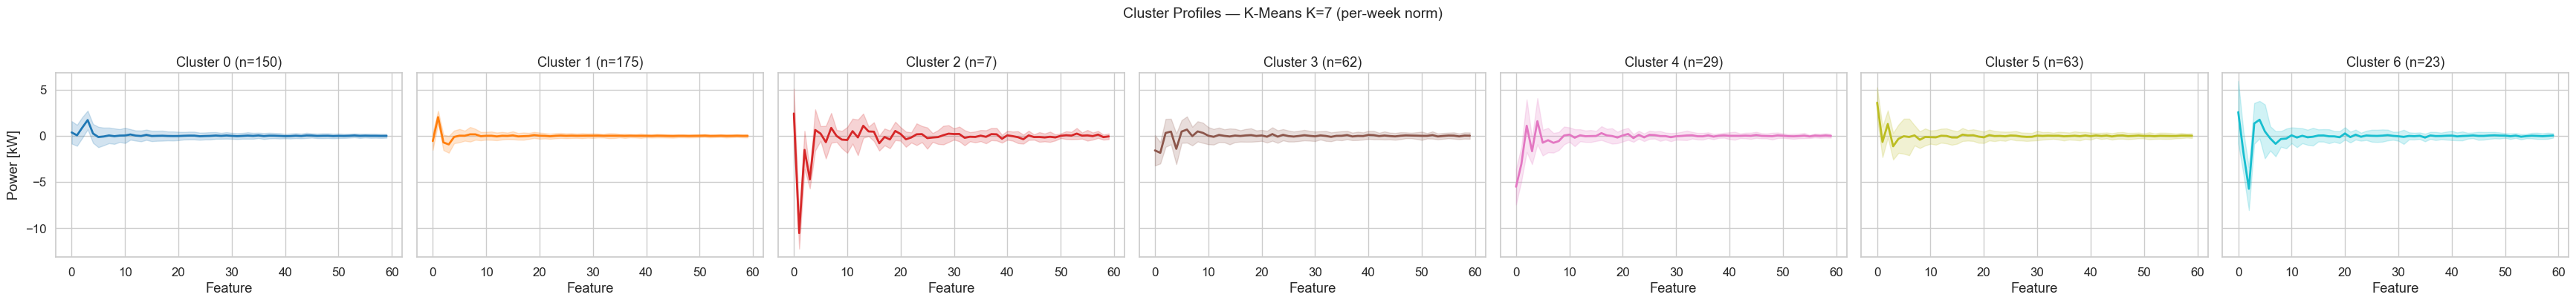

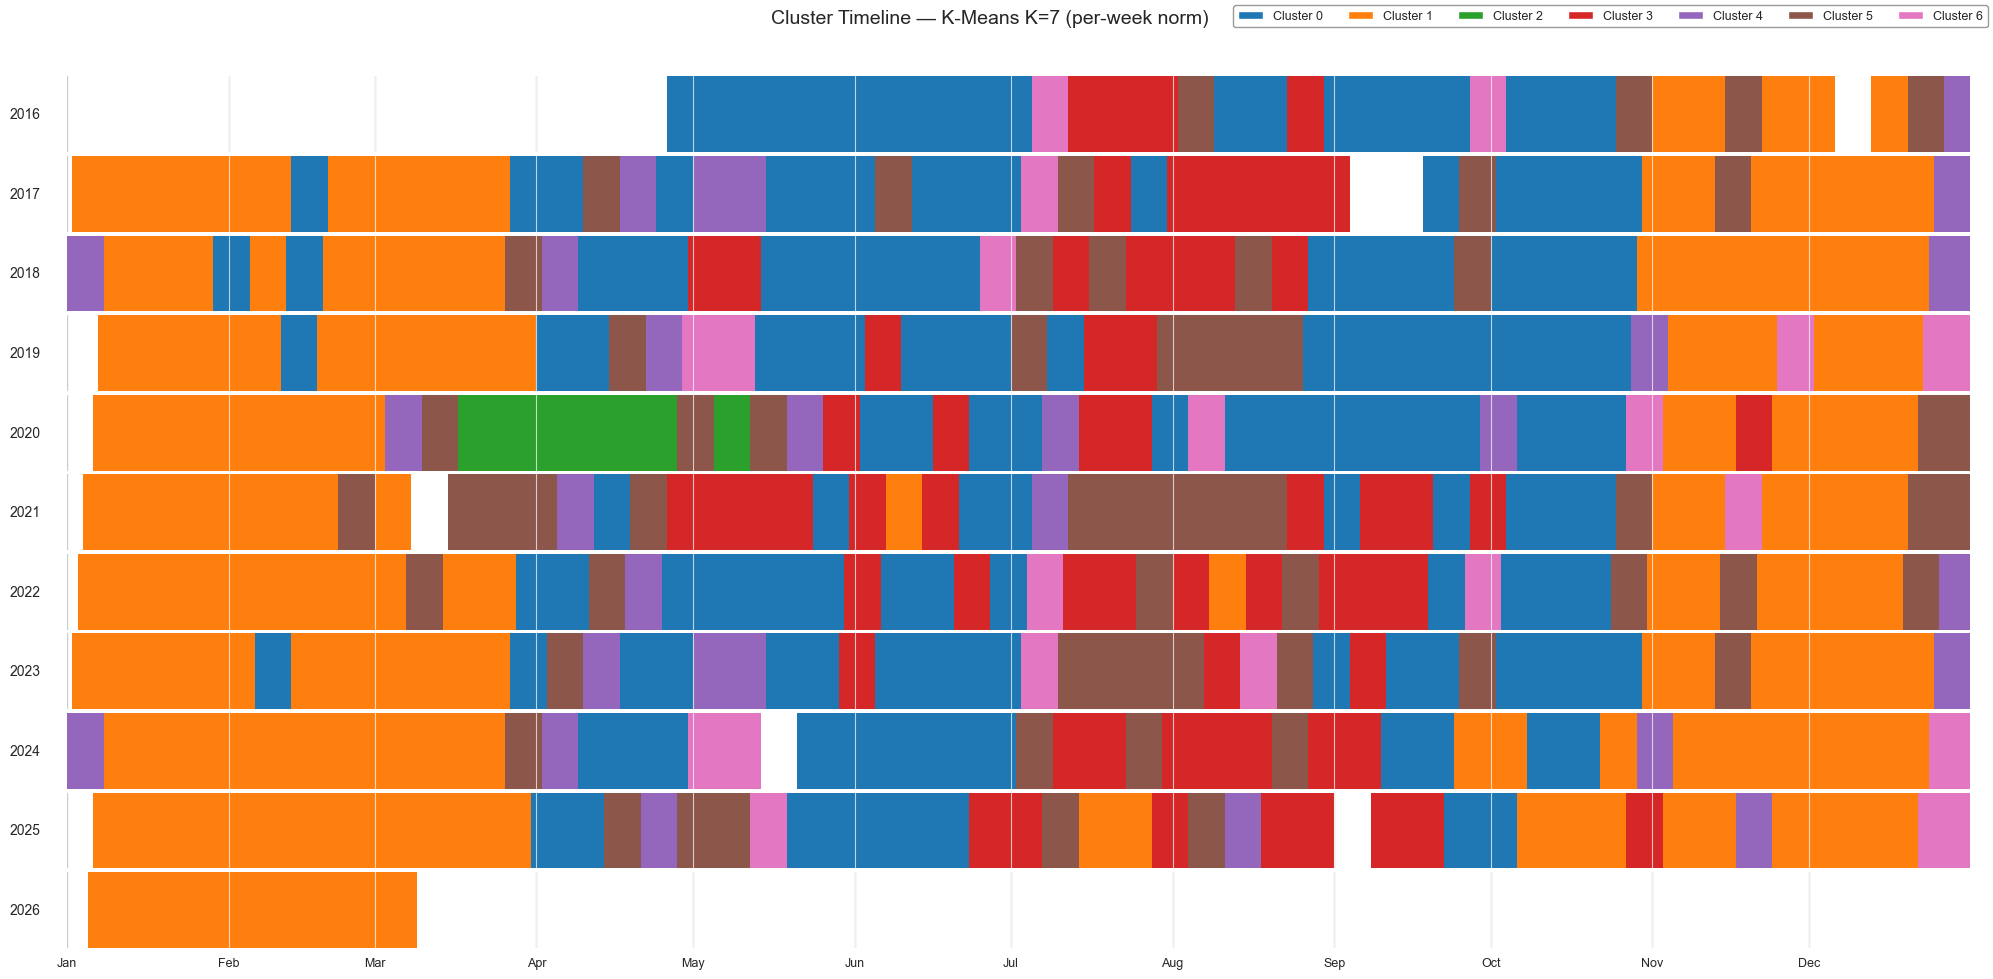

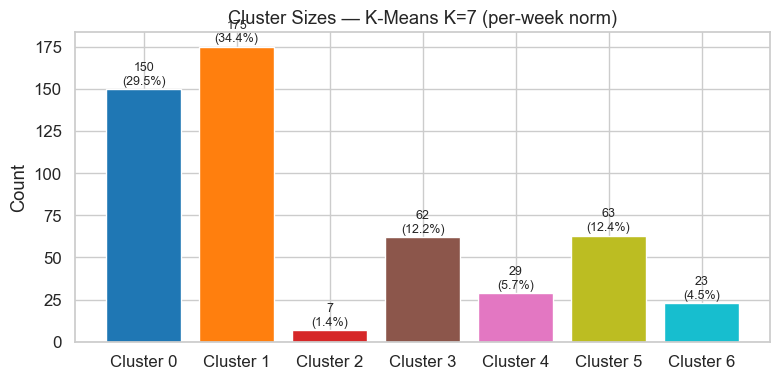

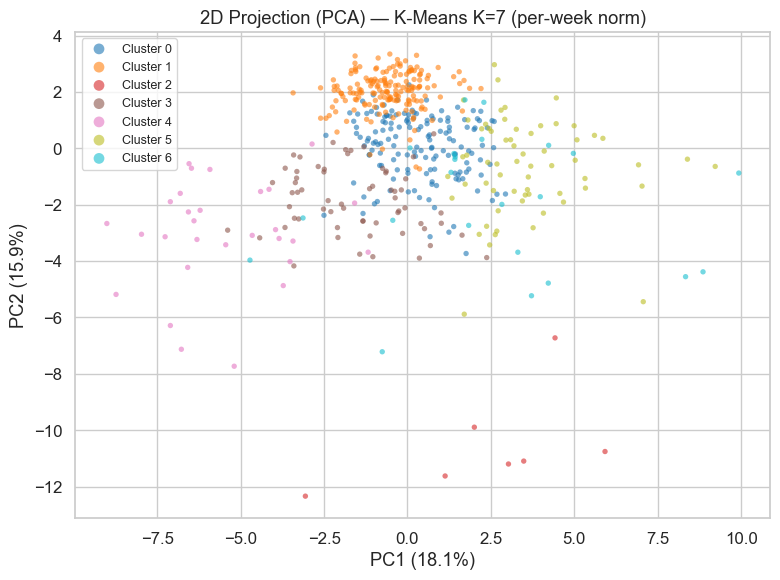

In [39]:
K_KM = 7  # <-- adjust after inspecting plots above

km = KMeans(n_clusters=K_KM, n_init=10, random_state=42)
labels_km = km.fit_predict(X)

eval_km = ClusterEvaluator(X, labels_km, dates_weekly,
                           name=f"K-Means K={K_KM} ({NORM_LABEL})")
eval_km.plot_all()

---
## Model 2: GMM (Gaussian Mixture Model)

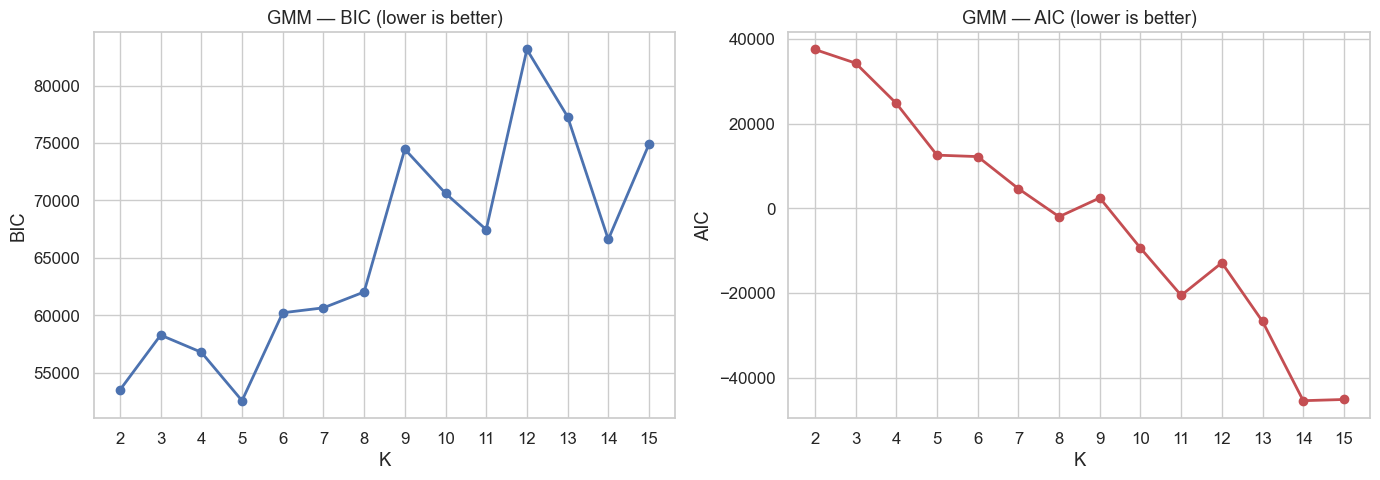

Best K by BIC: 5, by AIC: 14


In [40]:
# BIC/AIC model selection
K_range = range(2, 16)
bic_scores, aic_scores = [], []

for k in K_range:
    gmm = GaussianMixture(n_components=k, covariance_type="full",
                          n_init=5, random_state=42)
    gmm.fit(X)
    bic_scores.append(gmm.bic(X))
    aic_scores.append(gmm.aic(X))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.plot(list(K_range), bic_scores, "bo-", lw=2, ms=6)
ax1.set_xlabel("K"); ax1.set_ylabel("BIC")
ax1.set_title("GMM — BIC (lower is better)")
ax1.set_xticks(list(K_range))

ax2.plot(list(K_range), aic_scores, "ro-", lw=2, ms=6)
ax2.set_xlabel("K"); ax2.set_ylabel("AIC")
ax2.set_title("GMM — AIC (lower is better)")
ax2.set_xticks(list(K_range))
plt.tight_layout()
plt.show()

print(f"Best K by BIC: {list(K_range)[np.argmin(bic_scores)]}, "
      f"by AIC: {list(K_range)[np.argmin(aic_scores)]}")

GMM confidence: mean=1.00, min=0.98, <0.7: 0 weeks

  GMM K=7 (per-week norm) — K=7
  Silhouette score:       0.1365
  Calinski-Harabasz:      47.2
  Davies-Bouldin:         2.1014

  Per-cluster breakdown:
   Cluster   Size       %  Silhouette
  -----------------------------------
         0    185   36.3%     0.3351
         1    151   29.7%     0.0470
         2     19    3.7%     0.0405
         3     40    7.9%    -0.0419
         4     15    2.9%    -0.0305
         5     76   14.9%    -0.0603
         6     23    4.5%     0.2747



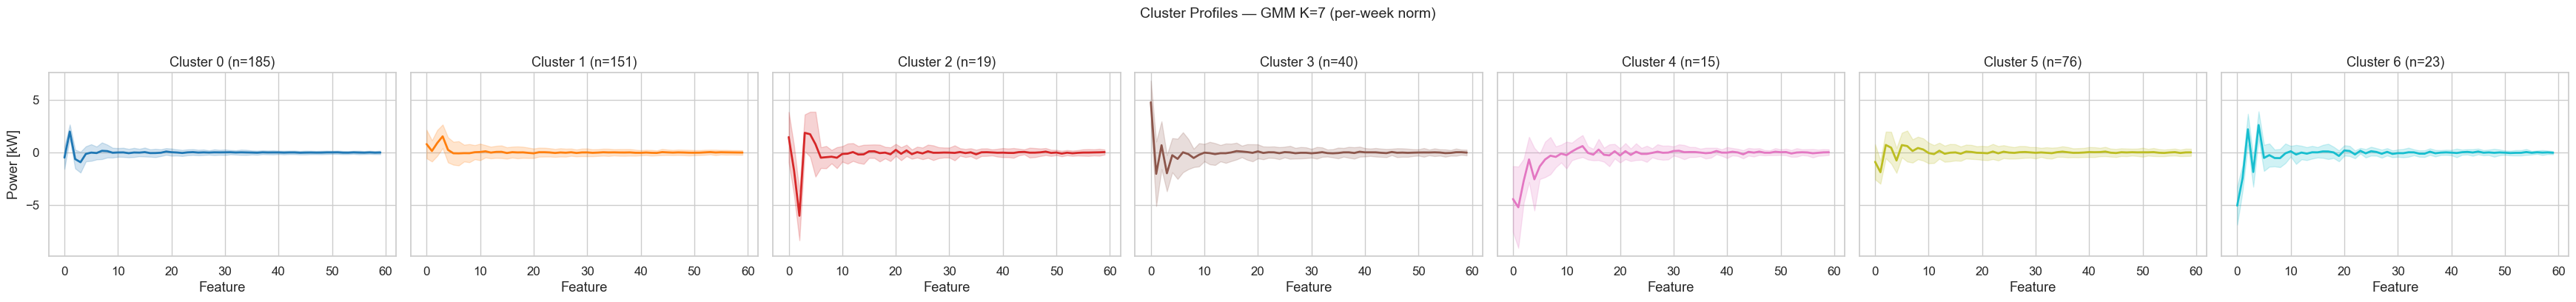

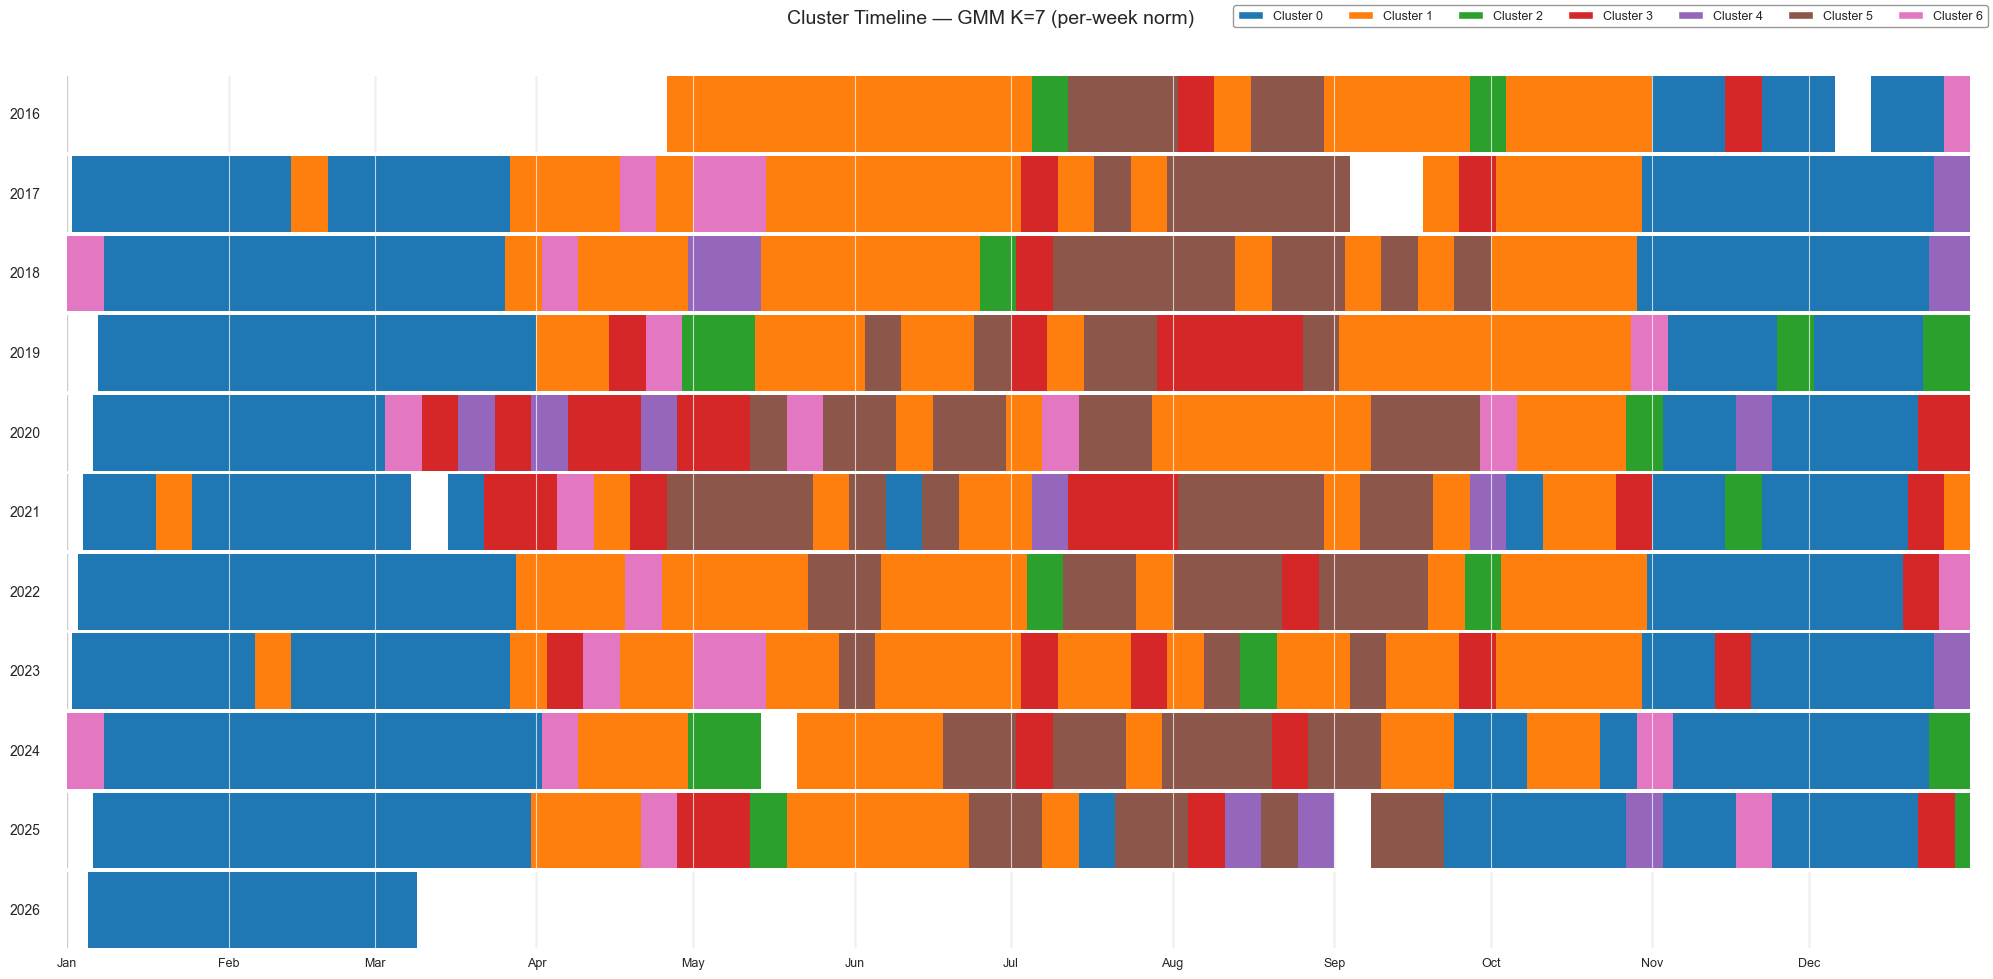

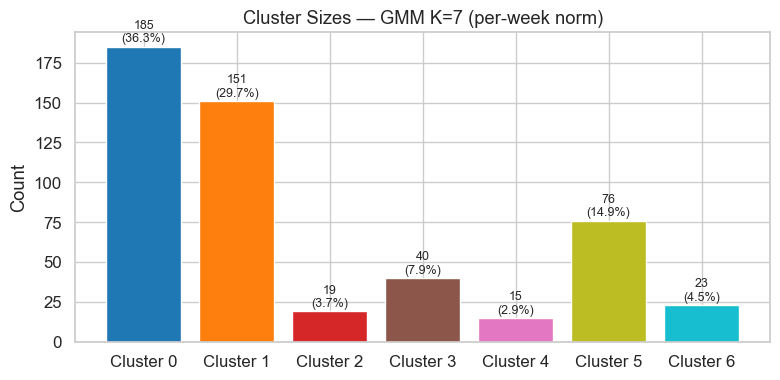

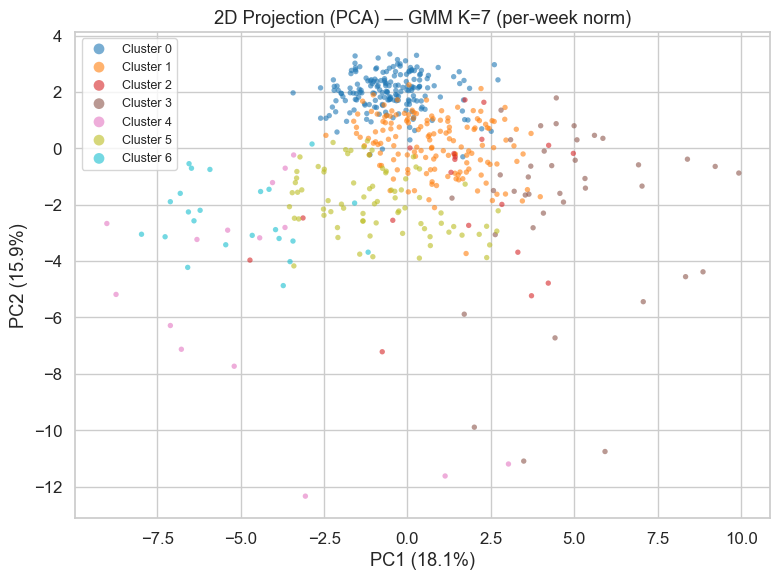

In [41]:
K_GMM = 7  # <-- adjust after inspecting BIC/AIC

gmm_final = GaussianMixture(n_components=K_GMM, covariance_type="full",
                            n_init=10, random_state=42)
gmm_final.fit(X)
labels_gmm = gmm_final.predict(X)
probs_gmm = gmm_final.predict_proba(X)

# Soft assignment confidence
max_prob = probs_gmm.max(axis=1)
print(f"GMM confidence: mean={max_prob.mean():.2f}, min={max_prob.min():.2f}, "
      f"<0.7: {(max_prob < 0.7).sum()} weeks")

eval_gmm = ClusterEvaluator(X, labels_gmm, dates_weekly,
                            name=f"GMM K={K_GMM} ({NORM_LABEL})")
eval_gmm.plot_all()

---
## Model 3: Hierarchical Clustering

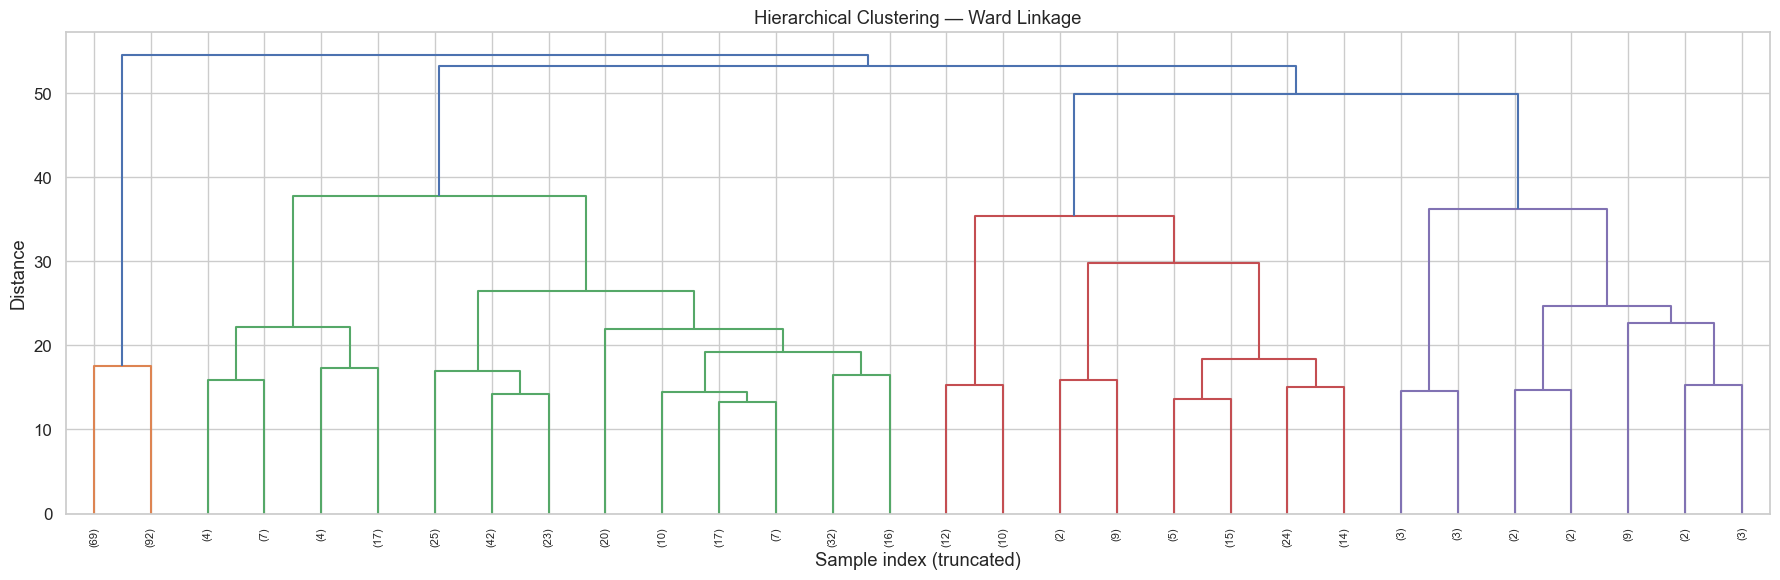

In [42]:
# Dendrogram (sampled if >500 points for readability)
n_samples = len(X)
if n_samples > 500:
    sample_idx = np.random.RandomState(42).choice(n_samples, 500, replace=False)
    X_sample = X[sample_idx]
else:
    X_sample = X

Z = linkage(X_sample, method="ward")

fig, ax = plt.subplots(figsize=(18, 6))
dendrogram(Z, ax=ax, truncate_mode="lastp", p=30,
           leaf_rotation=90, leaf_font_size=8,
           color_threshold=0.7 * max(Z[:, 2]))
ax.set_title("Hierarchical Clustering — Ward Linkage")
ax.set_xlabel("Sample index (truncated)")
ax.set_ylabel("Distance")
plt.tight_layout()
plt.show()


  Hierarchical K=7 (per-week norm) — K=7
  Silhouette score:       0.1237
  Calinski-Harabasz:      45.9
  Davies-Bouldin:         2.0027

  Per-cluster breakdown:
   Cluster   Size       %  Silhouette
  -----------------------------------
         0     65   12.8%    -0.1097
         1     86   16.9%    -0.0865
         2    166   32.6%     0.3801
         3     16    3.1%     0.0488
         4    146   28.7%     0.0422
         5      6    1.2%     0.2440
         6     24    4.7%     0.2505



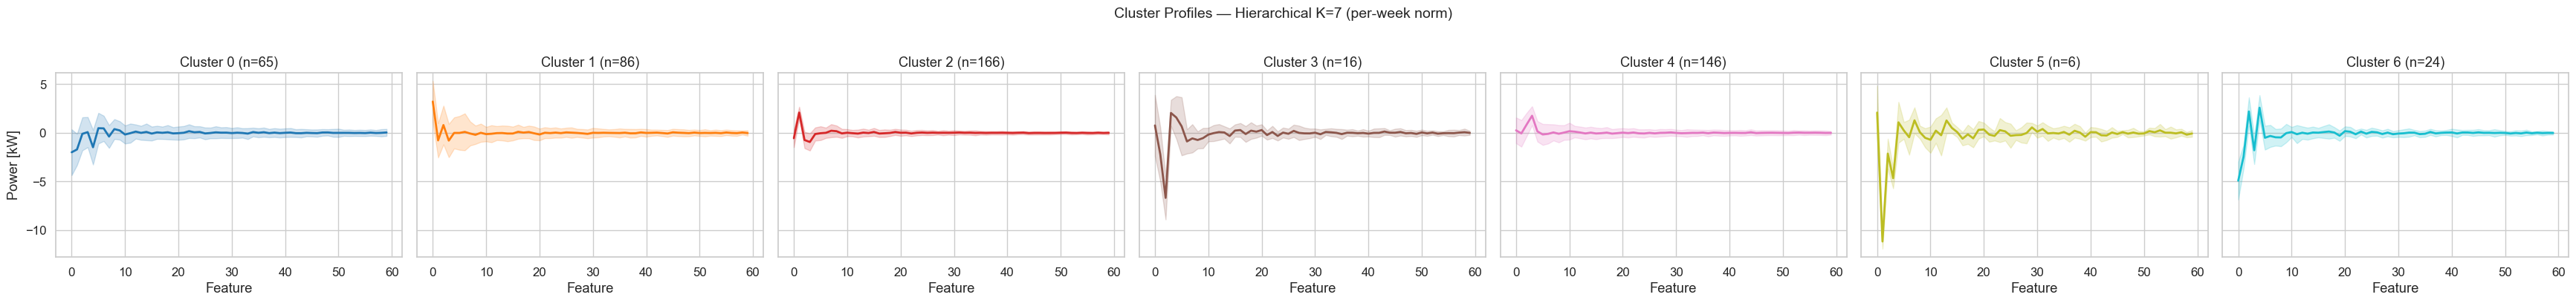

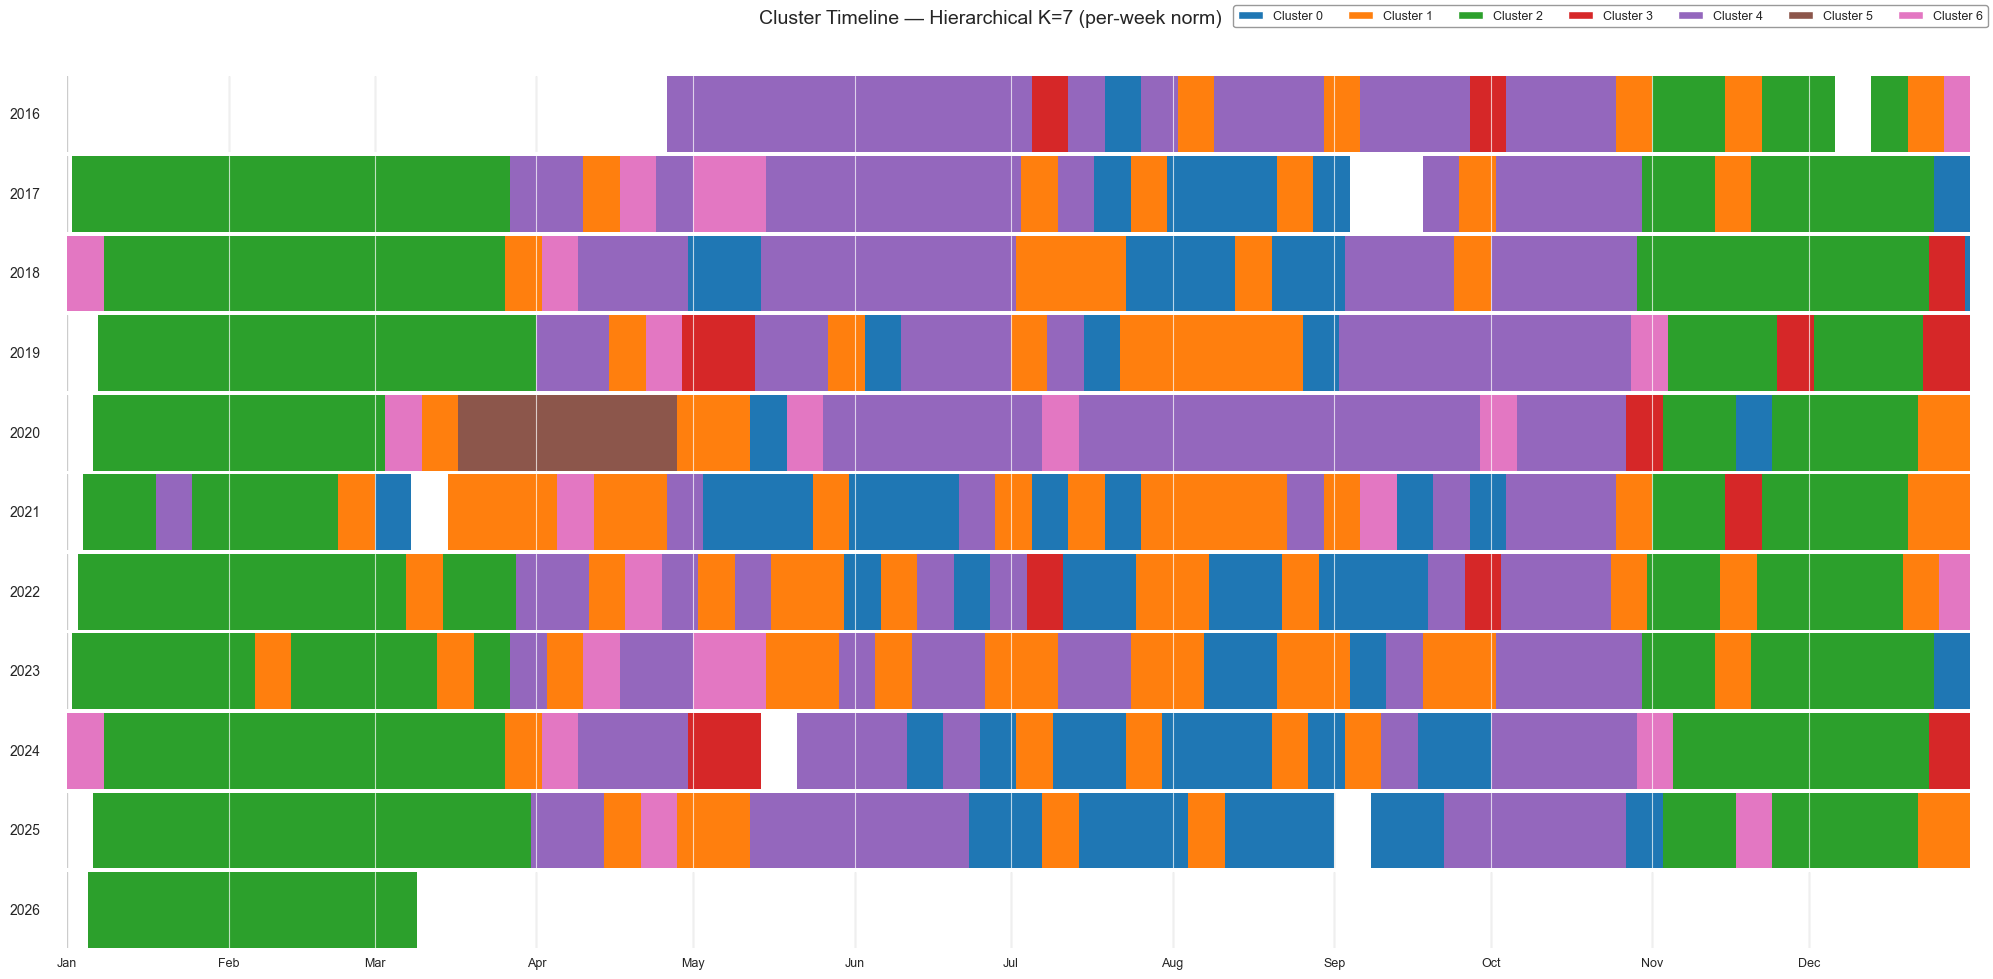

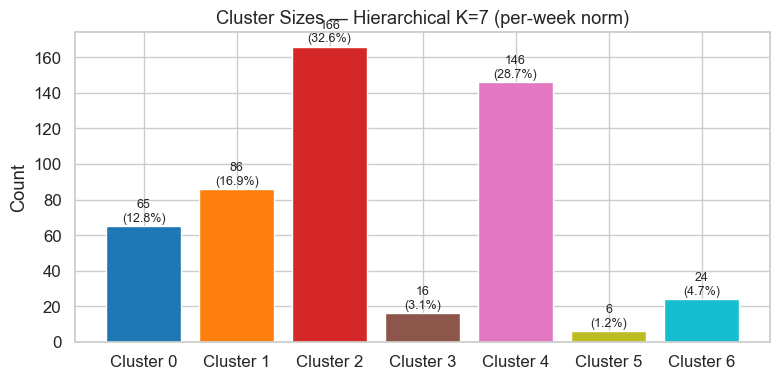

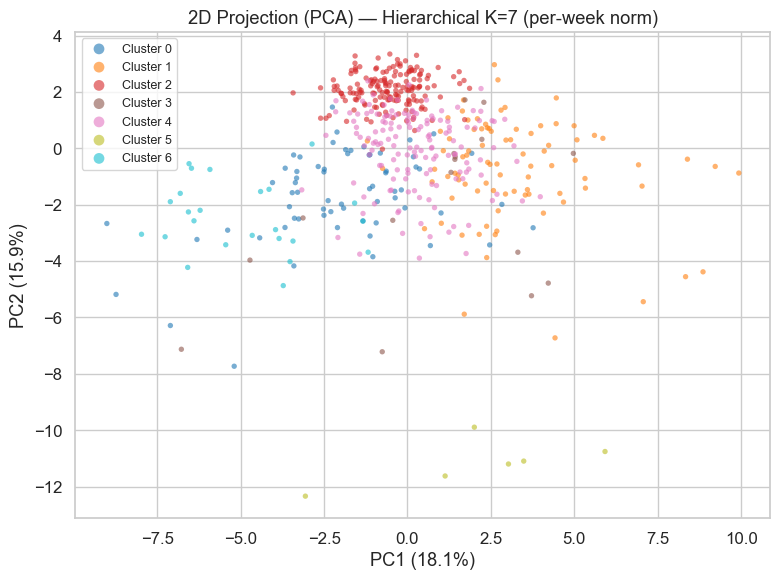

In [43]:
K_HIER = 7  # <-- adjust after inspecting dendrogram

hc = AgglomerativeClustering(n_clusters=K_HIER, linkage="ward")
labels_hier = hc.fit_predict(X)

eval_hier = ClusterEvaluator(X, labels_hier, dates_weekly,
                             name=f"Hierarchical K={K_HIER} ({NORM_LABEL})")
eval_hier.plot_all()

---
## Model 4: HMM (Hidden Markov Model)

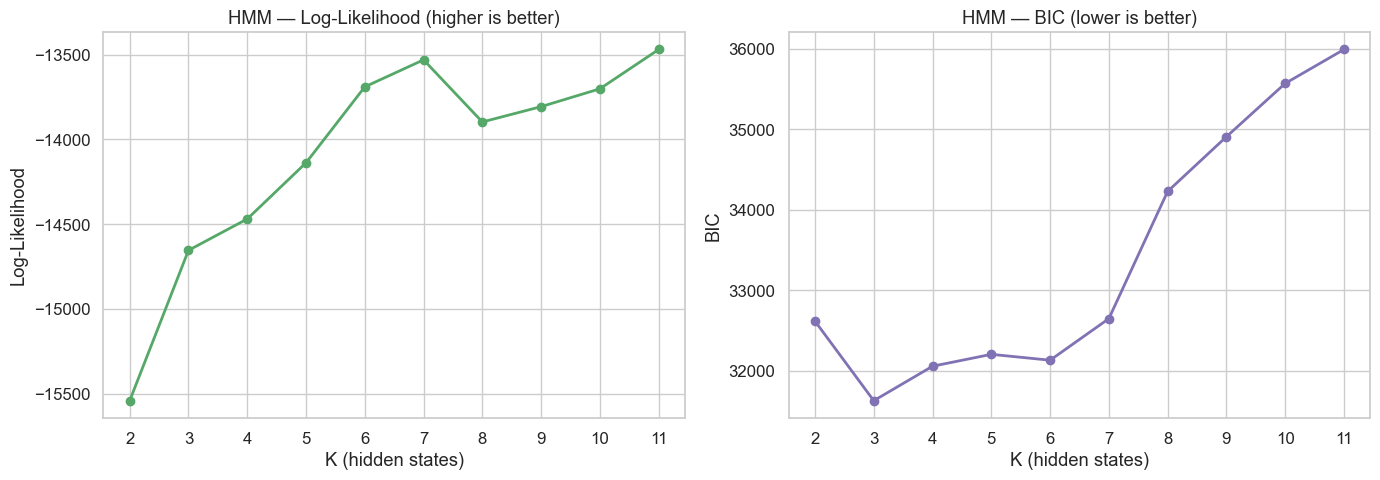

Best K by BIC: 3


In [44]:
# BIC-like model selection for HMM
K_hmm_range = range(2, 12)
hmm_scores = []

for k in K_hmm_range:
    hmm = GaussianHMM(n_components=k, covariance_type="diag",
                      n_iter=200, random_state=42, verbose=False)
    hmm.fit(X)
    ll = hmm.score(X)
    n_params = k * X.shape[1] * 2 + k * k + k
    bic = -2 * ll + n_params * np.log(len(X))
    hmm_scores.append({"k": k, "log_likelihood": ll, "bic": bic})

hmm_df = pd.DataFrame(hmm_scores)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.plot(hmm_df["k"], hmm_df["log_likelihood"], "go-", lw=2, ms=6)
ax1.set_xlabel("K (hidden states)"); ax1.set_ylabel("Log-Likelihood")
ax1.set_title("HMM — Log-Likelihood (higher is better)")
ax1.set_xticks(list(K_hmm_range))

ax2.plot(hmm_df["k"], hmm_df["bic"], "mo-", lw=2, ms=6)
ax2.set_xlabel("K (hidden states)"); ax2.set_ylabel("BIC")
ax2.set_title("HMM — BIC (lower is better)")
ax2.set_xticks(list(K_hmm_range))
plt.tight_layout()
plt.show()

print(f"Best K by BIC: {hmm_df.loc[hmm_df['bic'].idxmin(), 'k']}")

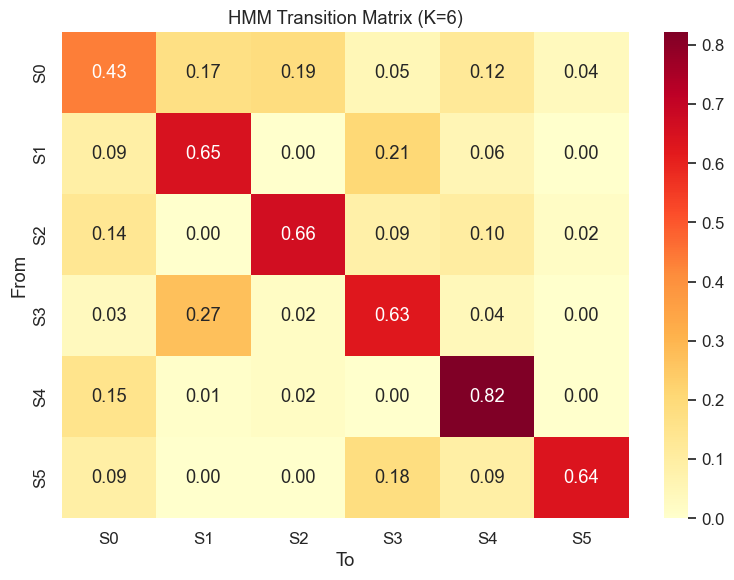


  HMM K=6 (per-week norm) — K=6
  Silhouette score:       -0.0447
  Calinski-Harabasz:      22.4
  Davies-Bouldin:         4.0421

  Per-cluster breakdown:
   Cluster   Size       %  Silhouette
  -----------------------------------
         0     80   15.7%    -0.2162
         1    114   22.4%    -0.0686
         2     59   11.6%     0.3015
         3     91   17.9%    -0.1738
         4    154   30.3%    -0.0025
         5     11    2.2%     0.0711



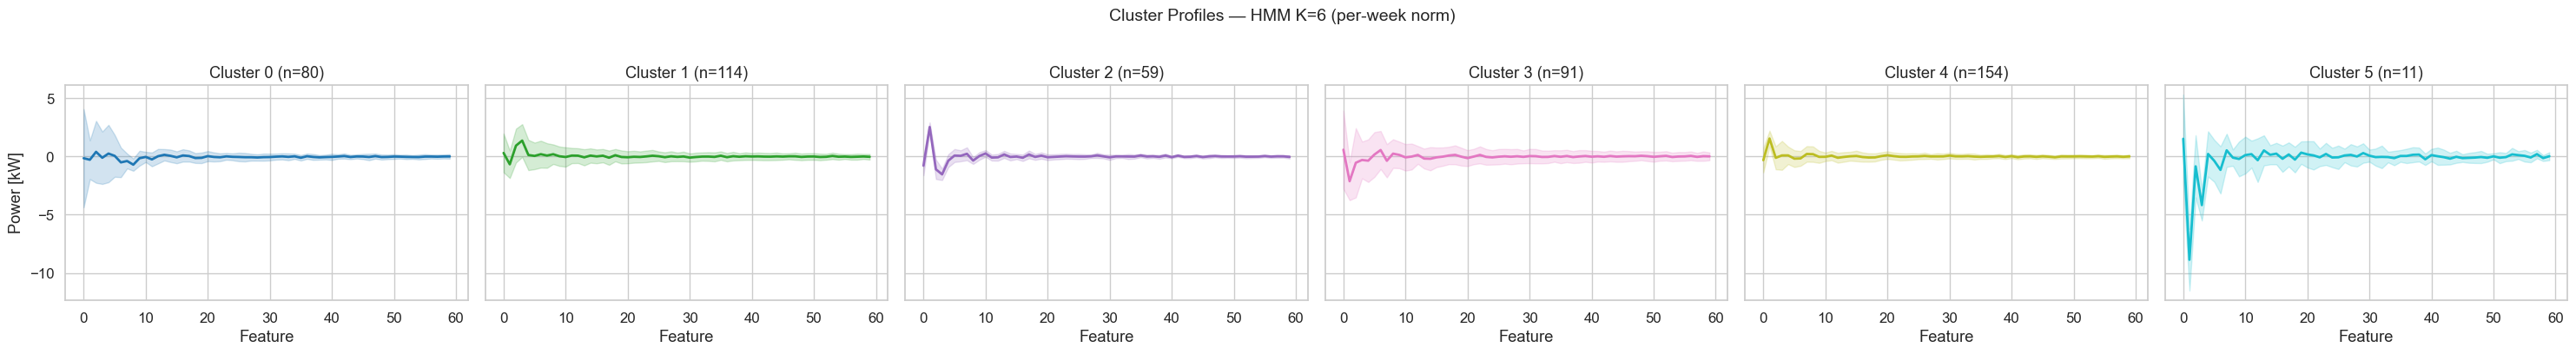

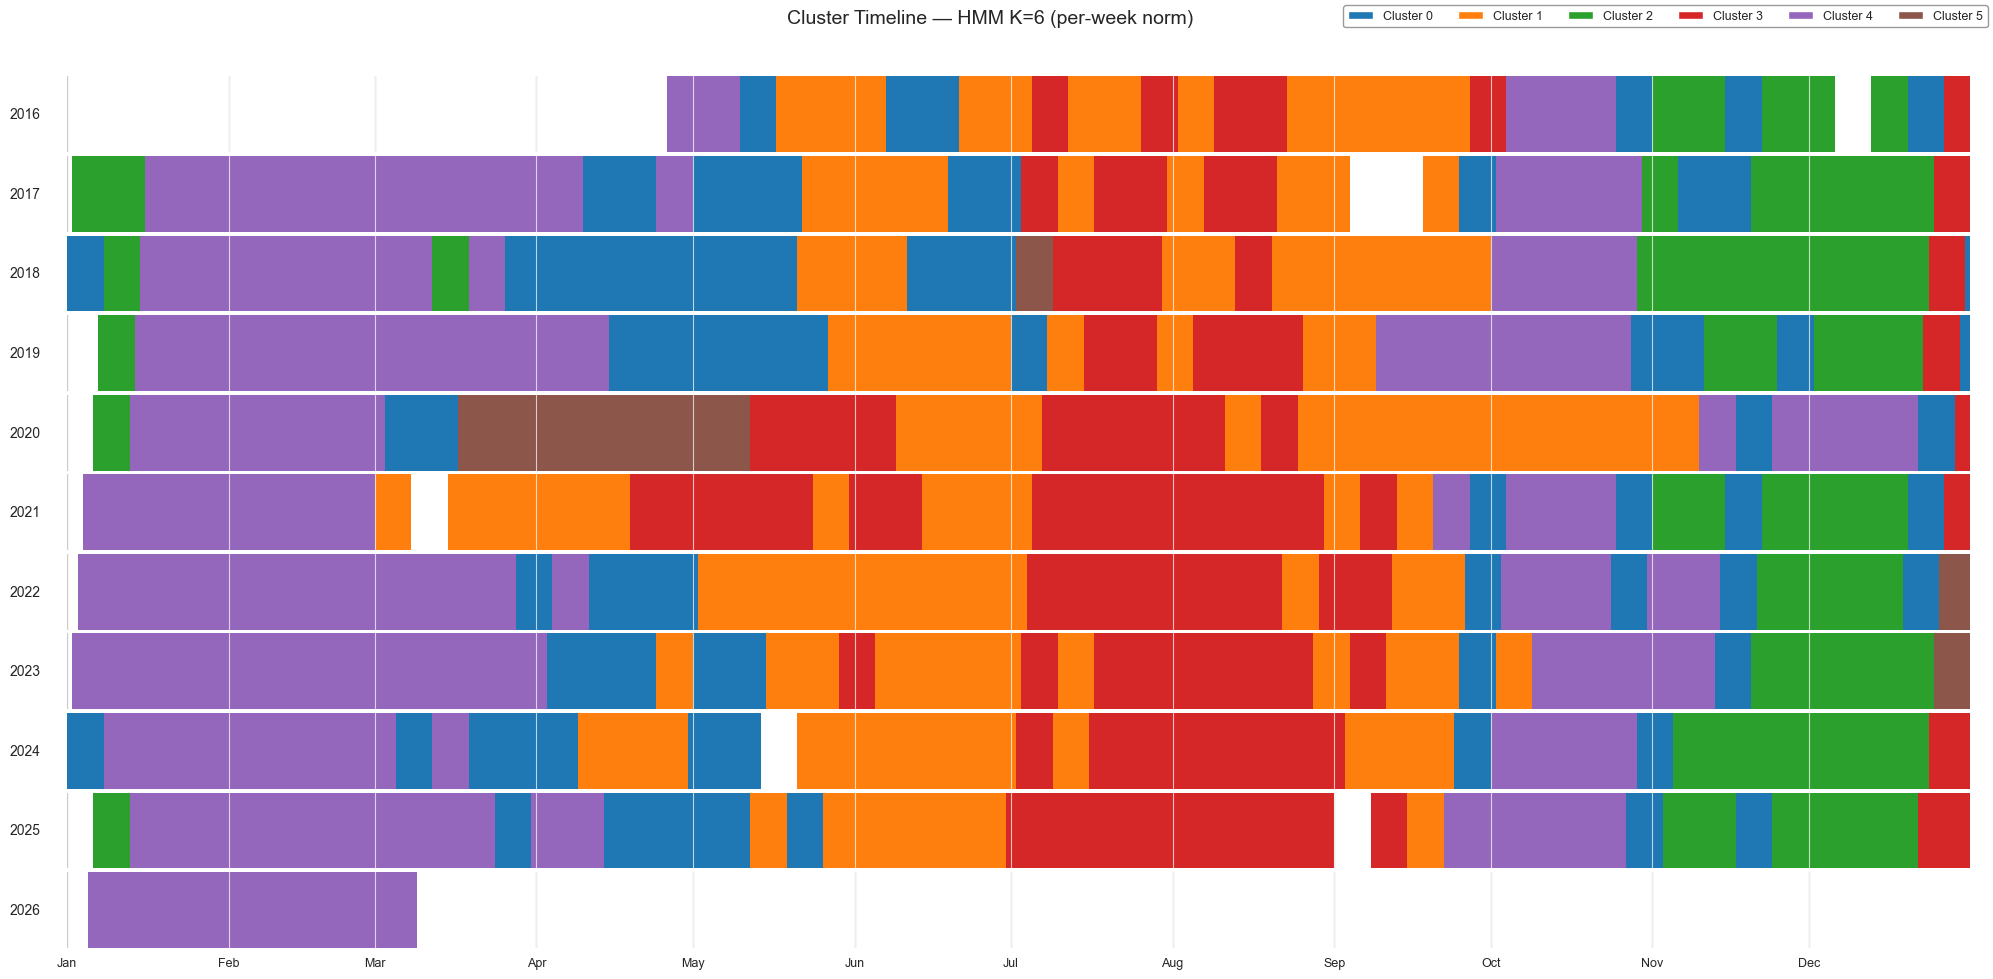

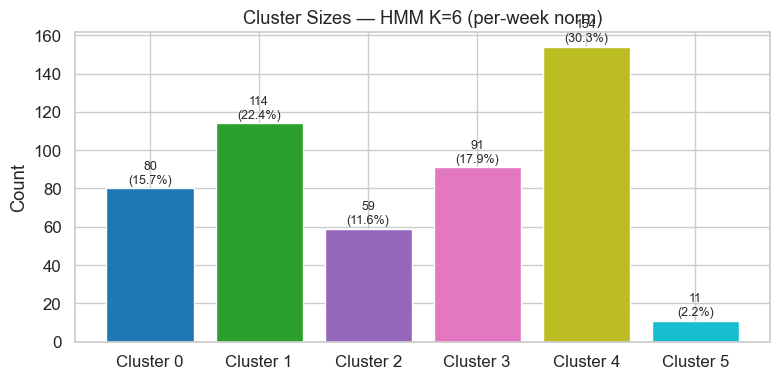

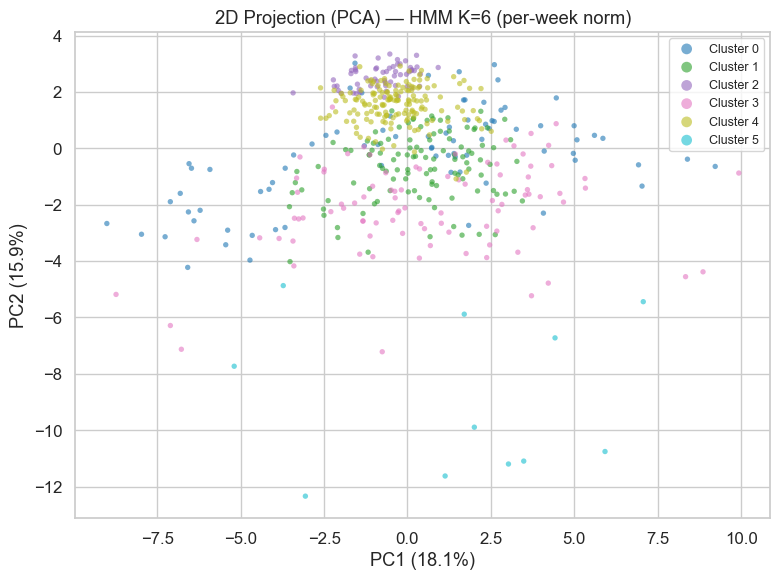

In [45]:
K_HMM = 6  # <-- adjust after inspecting

hmm_final = GaussianHMM(n_components=K_HMM, covariance_type="diag",
                        n_iter=300, random_state=42, verbose=False)
hmm_final.fit(X)
labels_hmm = hmm_final.predict(X)

# Transition matrix
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(hmm_final.transmat_, annot=True, fmt=".2f", cmap="YlOrRd",
            xticklabels=[f"S{i}" for i in range(K_HMM)],
            yticklabels=[f"S{i}" for i in range(K_HMM)], ax=ax)
ax.set_title(f"HMM Transition Matrix (K={K_HMM})")
ax.set_xlabel("To"); ax.set_ylabel("From")
plt.tight_layout()
plt.show()

eval_hmm = ClusterEvaluator(X, labels_hmm, dates_weekly,
                            name=f"HMM K={K_HMM} ({NORM_LABEL})")
eval_hmm.plot_all()

---
## Model 5: Change Point Detection (PELT)

In [46]:
# Try different penalty values
print("Penalty scan:")
for pen in [5, 10, 20, 50]:
    algo = rpt.Pelt(model="l2", min_size=3).fit(X)
    cps = algo.predict(pen=pen)
    print(f"  pen={pen:>3}: {len(cps)} segments")

Penalty scan:
  pen=  5: 102 segments
  pen= 10: 101 segments
  pen= 20: 86 segments
  pen= 50: 54 segments


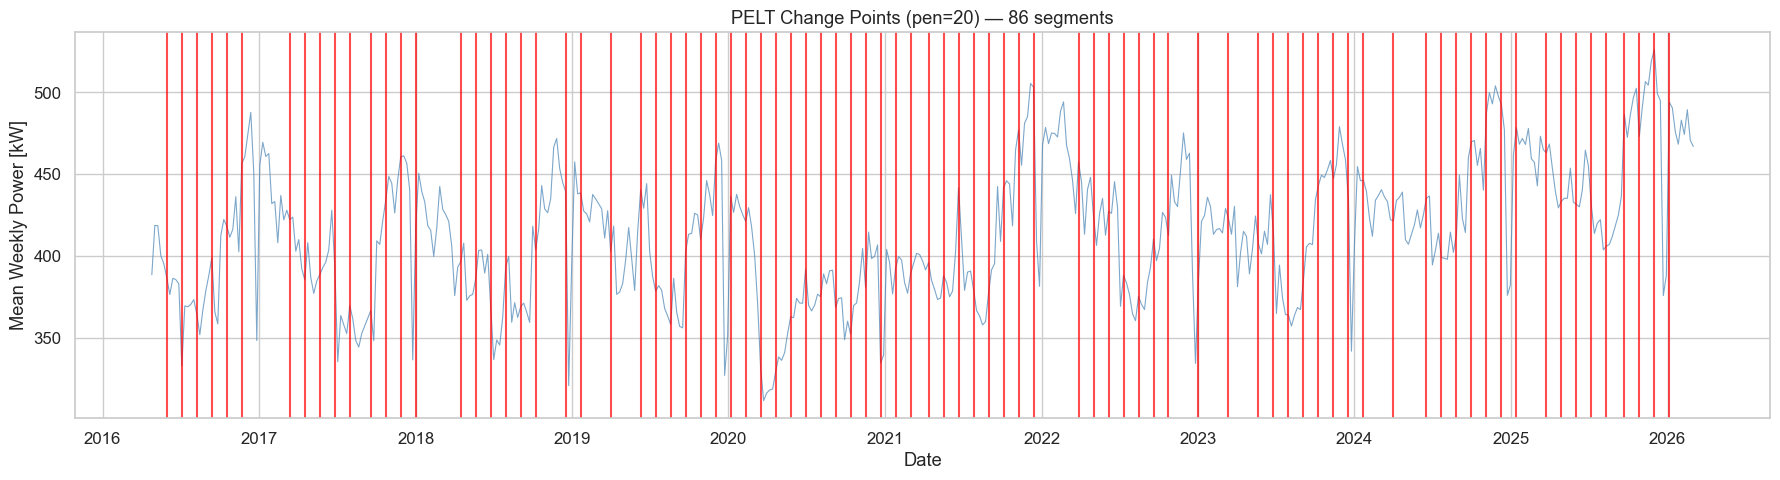

PELT: 86 segments


In [47]:
PEN = 20  # <-- adjust after inspecting

algo = rpt.Pelt(model="l2", min_size=3).fit(X)
change_points = algo.predict(pen=PEN)
n_segments = len(change_points)

# Assign segment labels
labels_cp = np.zeros(len(X), dtype=int)
prev = 0
for seg_id, cp in enumerate(change_points):
    labels_cp[prev:cp] = seg_id
    prev = cp

# Visualize change points on weekly mean consumption
weekly_mean = weekly_pivot.mean(axis=1)

fig, ax = plt.subplots(figsize=(18, 5))
ax.plot(dates_weekly, weekly_mean.values, lw=0.8, color="steelblue", alpha=0.7)
for cp in change_points[:-1]:
    if cp < len(dates_weekly):
        ax.axvline(dates_weekly[cp], color="red", lw=1.5, alpha=0.7)
ax.set_xlabel("Date"); ax.set_ylabel("Mean Weekly Power [kW]")
ax.set_title(f"PELT Change Points (pen={PEN}) — {n_segments} segments")
plt.tight_layout()
plt.show()

print(f"PELT: {n_segments} segments")

86 segments clustered into 7 regime types

  PELT+KMeans K=7 (per-week norm) — K=7
  Silhouette score:       0.0398
  Calinski-Harabasz:      20.7
  Davies-Bouldin:         3.2872

  Per-cluster breakdown:
   Cluster   Size       %  Silhouette
  -----------------------------------
         0    179   35.2%     0.1918
         1     55   10.8%    -0.0876
         2     25    4.9%    -0.0165
         3     45    8.8%    -0.1247
         4    135   26.5%    -0.0537
         5     60   11.8%     0.0573
         6     10    2.0%     0.0559



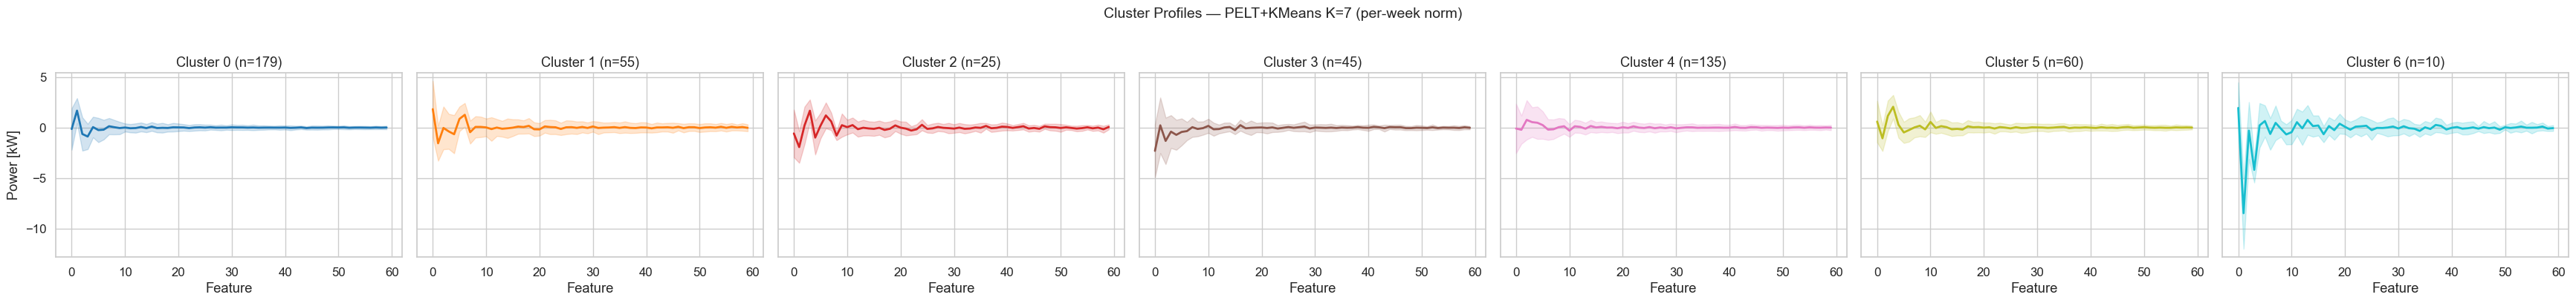

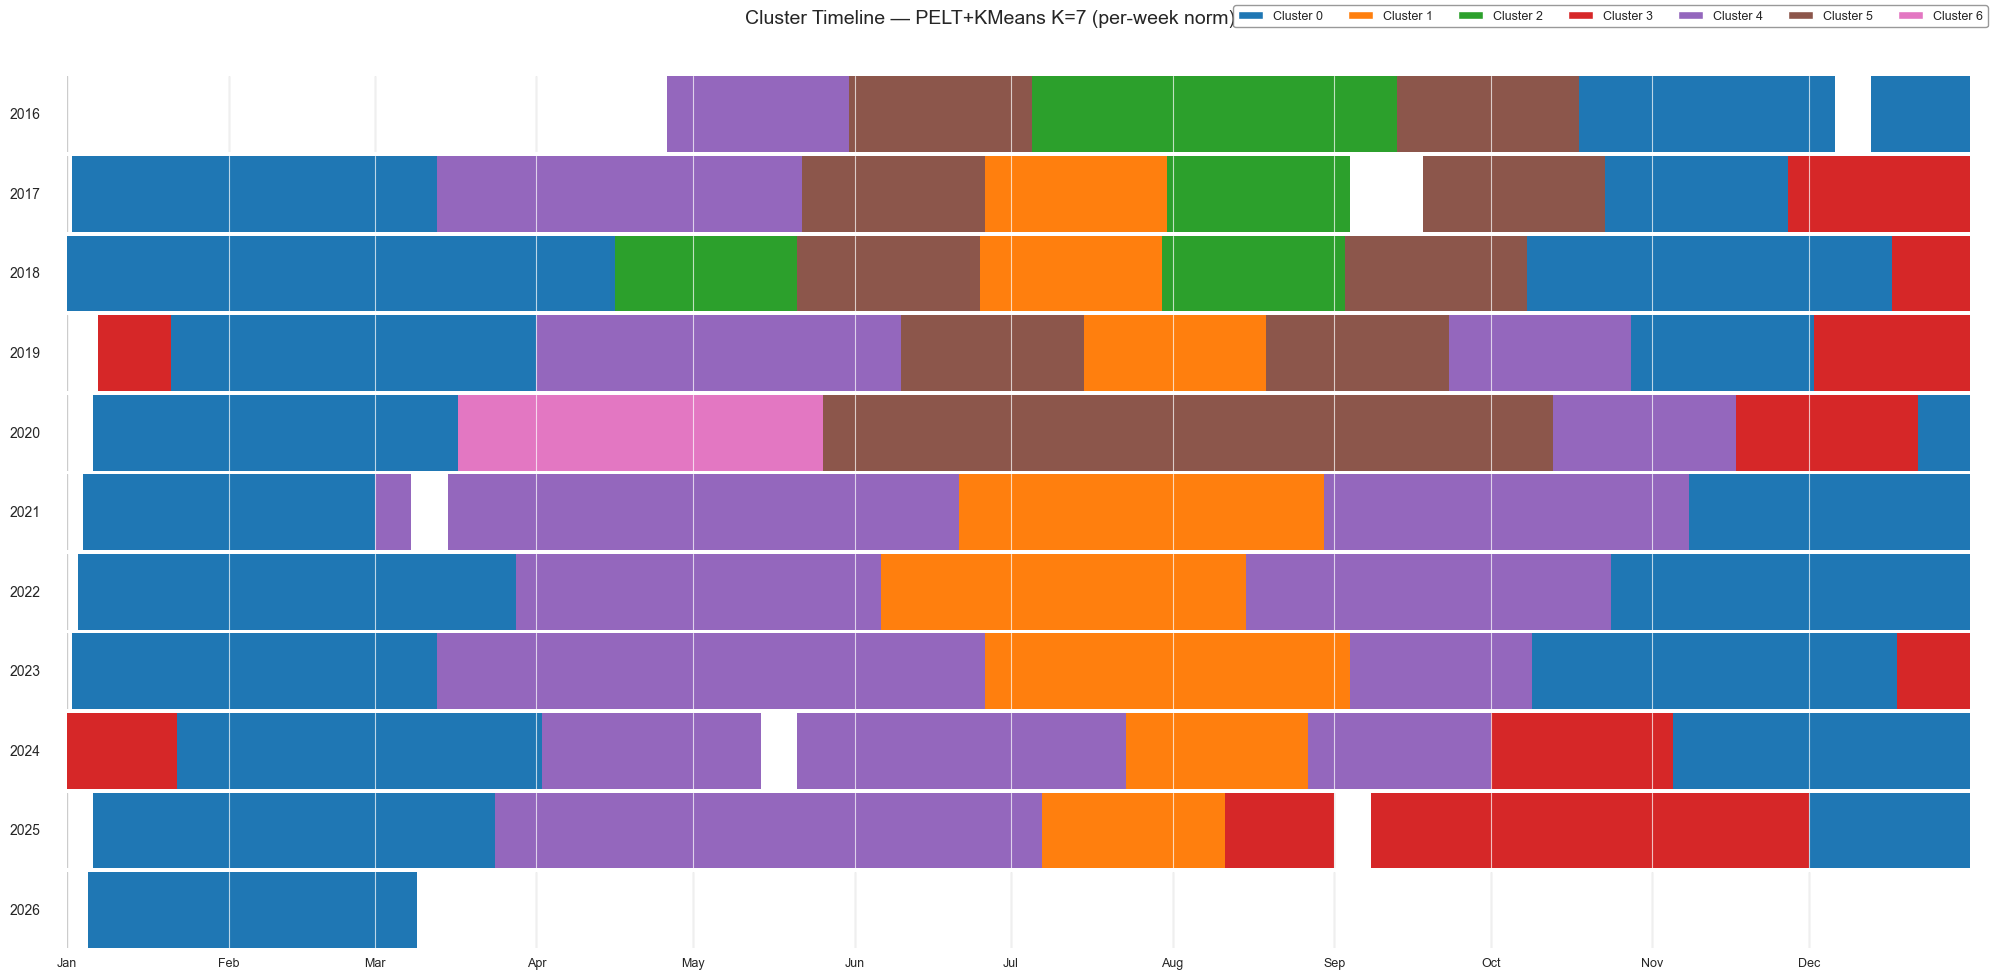

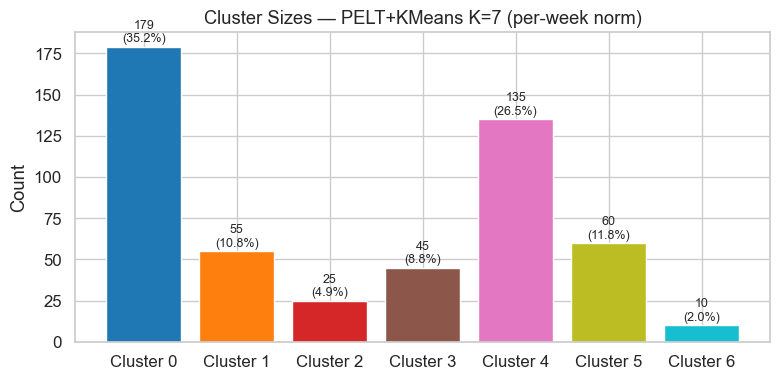

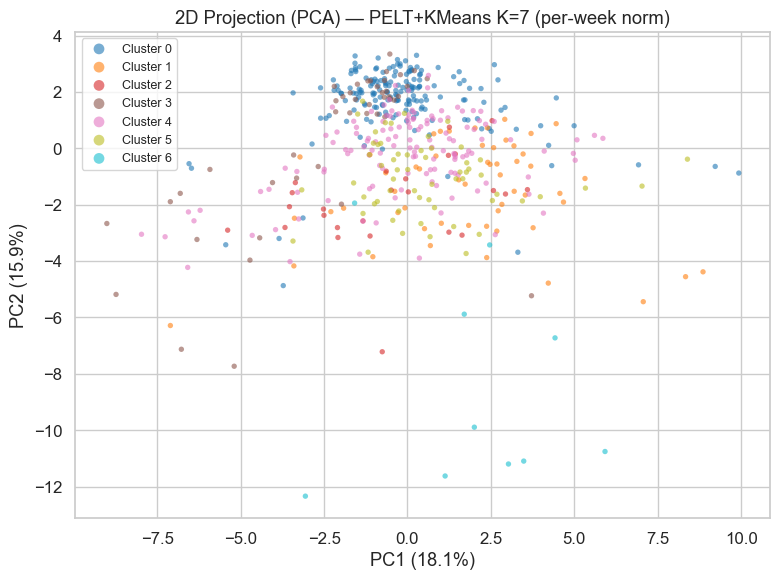

In [48]:
# If too many segments, cluster them into regime types
if n_segments > 15:
    segment_features = []
    prev = 0
    for cp in change_points:
        segment_features.append(X[prev:cp].mean(axis=0))
        prev = cp
    segment_features = np.array(segment_features)

    K_SEG = 7
    km_seg = KMeans(n_clusters=K_SEG, n_init=10, random_state=42)
    seg_labels = km_seg.fit_predict(segment_features)

    labels_cp_final = np.zeros(len(X), dtype=int)
    prev = 0
    for seg_id, cp in enumerate(change_points):
        labels_cp_final[prev:cp] = seg_labels[seg_id]
        prev = cp

    print(f"{n_segments} segments clustered into {K_SEG} regime types")
    cp_name = f"PELT+KMeans K={K_SEG}"
else:
    labels_cp_final = labels_cp
    cp_name = f"PELT pen={PEN}"
    print(f"Using {n_segments} segments directly")

eval_cp = ClusterEvaluator(X, labels_cp_final, dates_weekly,
                           name=f"{cp_name} ({NORM_LABEL})")
eval_cp.plot_all()

---
## 6. Side-by-Side Model Comparison

In [49]:
all_results = {
    f"K-Means (K={K_KM})": labels_km,
    f"GMM (K={K_GMM})": labels_gmm,
    f"Hierarchical (K={K_HIER})": labels_hier,
    f"HMM (K={K_HMM})": labels_hmm,
    cp_name: labels_cp_final,
}

# Scores table
print(f"{'Model':<25} {'Silhouette':>10} {'CH':>10} {'DB':>8}")
print("-" * 55)
for name, labels in all_results.items():
    ev = ClusterEvaluator(X, labels, dates_weekly, name=name)
    s = ev.scores()
    print(f"{name:<25} {s['silhouette']:>10.4f} {s['calinski_harabasz']:>10.1f} "
          f"{s['davies_bouldin']:>8.4f}")

Model                     Silhouette         CH       DB
-------------------------------------------------------
K-Means (K=7)                 0.1364       51.2   1.9982
GMM (K=7)                     0.1365       47.2   2.1014
Hierarchical (K=7)            0.1237       45.9   2.0027
HMM (K=6)                    -0.0447       22.4   4.0421
PELT+KMeans K=7               0.0398       20.7   3.2872


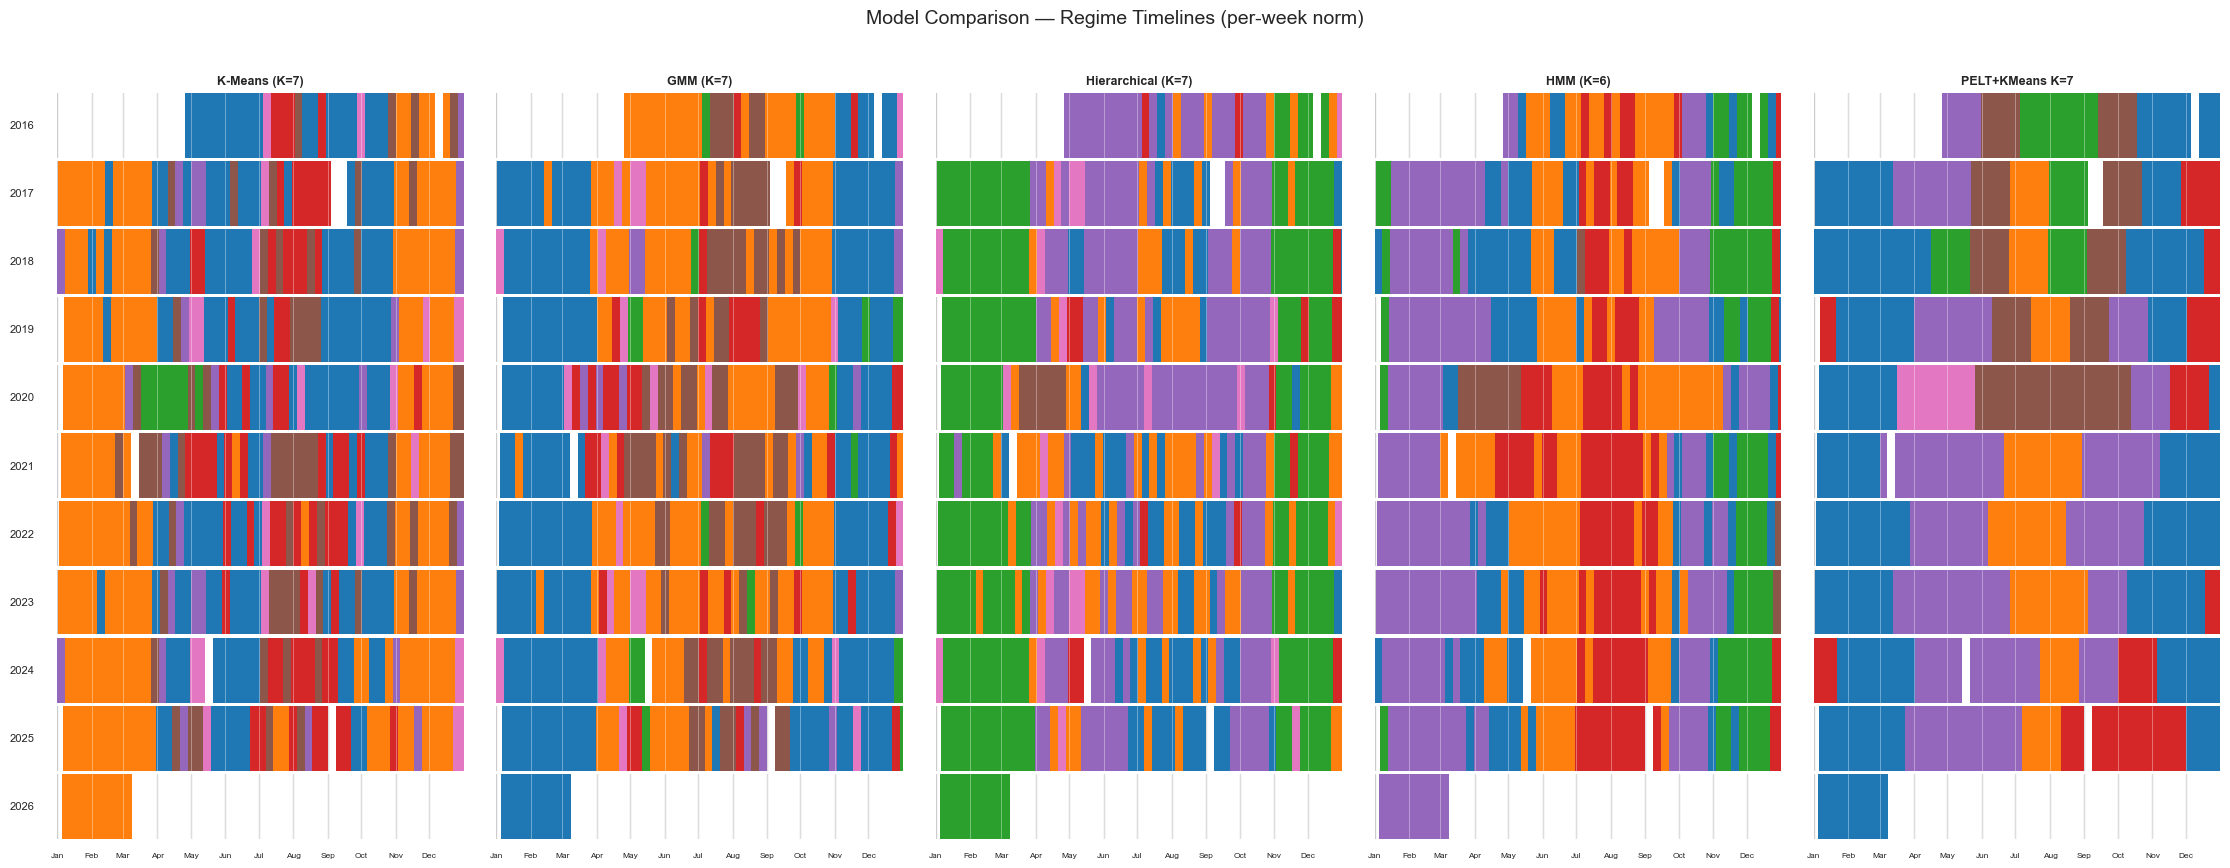

In [50]:
# Side-by-side timelines
n_models = len(all_results)
years = sorted(set(dates_weekly.year))
n_years = len(years)

month_names = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
               "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
month_starts = [1, 32, 60, 91, 121, 152, 182, 213, 244, 274, 305, 335]

fig, axes = plt.subplots(n_years, n_models,
                         figsize=(4.5 * n_models, 0.6 * n_years + 2),
                         sharex=True, squeeze=False)

for col, (model_name, labels) in enumerate(all_results.items()):
    n_clusters = len(np.unique(labels))
    colors_list = plt.cm.tab10(np.linspace(0, 1, max(n_clusters, 10)))[:n_clusters]
    unique_labels = sorted(np.unique(labels))
    label_to_idx = {l: i for i, l in enumerate(unique_labels)}

    for row, year in enumerate(years):
        ax = axes[row, col]
        year_mask = dates_weekly.year == year
        year_dates = dates_weekly[year_mask]
        year_labels = labels[year_mask]
        doy = year_dates.dayofyear

        for d, label in zip(doy, year_labels):
            color = colors_list[label_to_idx[label]]
            ax.barh(0, 7, left=d, height=1, color=color, edgecolor="none")

        ax.set_yticks([])
        ax.set_xlim(1, 366)
        ax.set_ylim(-0.5, 0.5)

        for ms in month_starts[1:]:
            ax.axvline(ms, color="white", lw=0.5, alpha=0.5)

        if row == 0:
            ax.set_title(model_name, fontsize=9, fontweight="bold")
        if col == 0:
            ax.set_ylabel(str(year), fontsize=8, rotation=0, labelpad=25, va="center")

        ax.set_xticks(month_starts)
        ax.set_xticklabels(month_names if row == n_years - 1 else [], fontsize=6)
        for spine in ax.spines.values():
            spine.set_visible(False)

plt.suptitle(f"Model Comparison — Regime Timelines ({NORM_LABEL})", fontsize=14, y=1.01)
plt.tight_layout()
plt.subplots_adjust(hspace=0.05, wspace=0.08)
plt.show()

---
## Notes

**To compare normalizations:** Change `USE_PERWEEK` in section 4 and re-run all model cells.

**To adjust K:** Each model has a `K_*` variable — inspect the model selection plots first, then set K and re-run that model's cells.

**Expected regimes** (Czech university):
1. Winter semester (Oct – mid Dec)
2. Christmas holidays (mid Dec – early Jan)
3. Winter exam period (Jan – mid Feb)
4. Summer semester (mid Feb – mid May)
5. Summer exam period (mid May – end Jun)
6. Summer holidays (Jul – Aug)
7. Autumn pre-semester (Sep)
8. COVID anomaly (2020-2021)